In [44]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

products = "/media/faraz/Data/Thesis/Archive/batpipeline_v2/products"

* These are with the old ad hoc tools only:

Mark1 - uniform binning

Mark2 - infile binning

Note from v1 - Use timebinalg as infile again. uniform is fucking shit up. Get uniform bins through rebingausslc task at the end on the master file.

Mark3 - rebingausslc binning


* Test with newer tools and time filtering too:

Mark 4 - ?

In [ ]:
"""
lc1 : Location of the FINAL.lc file from this pipeline.
lc2 : Location of the file downloaded from the BAT transient monitor website.

The website - https://swift.gsfc.nasa.gov/results/transients/

Note: This comparison is only valid for light curves in the 15-50 keV energy band, which is the same energy range 
used for the light curves provided on the Swift BAT transient monitor website.

"""

lc1 = ""
lc2 = ""

# lc1 -
with fits.open(lc1) as hdul:
    rate1_hdu = hdul["RATE1"]
    mjdref1 = rate1_hdu.header["MJDREFI"] + rate1_hdu.header["MJDREFF"]

    time1_sec = rate1_hdu.data['TIME']
    rate1 = rate1_hdu.data['RATE']
    err1  = rate1_hdu.data['ERROR']
    timedel1 = 1

time1 = mjdref1 + time1_sec / 86400.0

# lc2 -
with fits.open(lc2) as hdul:
    rate2_hdu = hdul["RATE"]
    time2 = rate2_hdu.data['TIME']
    rate2 = rate2_hdu.data['RATE']
    err2  = rate2_hdu.data['ERROR']


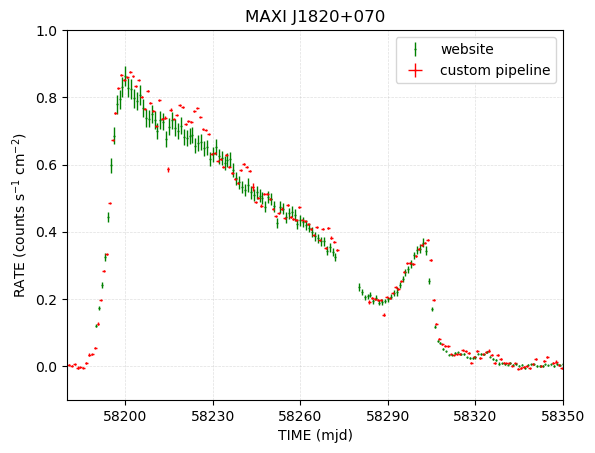

In [ ]:
plt.errorbar(time2, rate2, err2, fmt=".", ms=1, elinewidth=1, color="green", label="website")
plt.errorbar(time1, rate1, yerr=err1, xerr=1/2, fmt=".", color='r', ms=1, elinewidth=1, label="custom pipeline")


plt.title("MAXI J1820+070")
plt.xlabel("TIME (mjd)")
plt.ylabel(r"RATE (counts s$^{-1}$ cm$^{-2}$)")
plt.legend()
plt.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(30))

# plt.savefig(f"{products}/scrap.png", dpi=300)
plt.show()